In [9]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

from utils.trainer import fit, evaluate_classification
from utils.callbacks import ModelCheckpoint
from utils.visualizer import plot_training_curves
from utils.logger import save_run

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


## 1. Load and Prepare Dataset

In [11]:
# Load CSVs
train_df = pd.read_csv('csvs/train.csv')

X = train_df.drop(['label'], axis=1).values
y = train_df['label'].values

X = X.reshape(-1, 1, 28, 28)

if X.max() > 1:
    X = X / 255.0

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}")

Train shape: (33600, 1, 28, 28), Val shape: (8400, 1, 28, 28)


In [12]:
# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Create DataLoaders
batch_size = 128
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)

## 2. Define Model Architecture

In [13]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 3 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = DigitClassifier().to(device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 131,210


## 3. Training Loop

In [14]:
epochs = 20
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Mixed Precision Scaler
scaler = torch.amp.GradScaler('cuda')

checkpoint = ModelCheckpoint(
    model=model,
    checkpoint_path='./checkpoint/ultra_light_digit_checkpoint.pth',
    best_model_path='./checkpoint/best_ultra_light_digit_checkpoint.pth',
    mode='max',  # we want to maximize accuracy
    verbose=True,
)

# Run training using our utility
history = fit(
    model=model,
    task_type='classification',
    trainloader=train_loader,
    valloader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=epochs,
    scaler=scaler,
    checkpoint=checkpoint,
)

[ModelCheckpoint] New best (max): 98.0238 — saved to checkpoint\best_ultra_light_digit_checkpoint.pth
Epoch [ 1/20] | Train Loss: 0.2759 | Val Loss: 0.0620 | Val Acc: 98.02% | Time: 3.10s
[ModelCheckpoint] New best (max): 98.6905 — saved to checkpoint\best_ultra_light_digit_checkpoint.pth
Epoch [ 2/20] | Train Loss: 0.0763 | Val Loss: 0.0408 | Val Acc: 98.69% | Time: 1.03s
[ModelCheckpoint] New best (max): 98.8095 — saved to checkpoint\best_ultra_light_digit_checkpoint.pth
Epoch [ 3/20] | Train Loss: 0.0555 | Val Loss: 0.0389 | Val Acc: 98.81% | Time: 1.04s
Epoch [ 4/20] | Train Loss: 0.0428 | Val Loss: 0.0578 | Val Acc: 98.35% | Time: 1.06s
[ModelCheckpoint] New best (max): 98.9167 — saved to checkpoint\best_ultra_light_digit_checkpoint.pth
Epoch [ 5/20] | Train Loss: 0.0366 | Val Loss: 0.0336 | Val Acc: 98.92% | Time: 1.03s
Epoch [ 6/20] | Train Loss: 0.0330 | Val Loss: 0.0400 | Val Acc: 98.73% | Time: 1.02s
[ModelCheckpoint] New best (max): 99.1071 — saved to checkpoint\best_ultra_l

## 4. Evaluation and Visualization

[ModelCheckpoint] Restored best weights from checkpoint\best_ultra_light_digit_checkpoint.pth (score=99.1905)


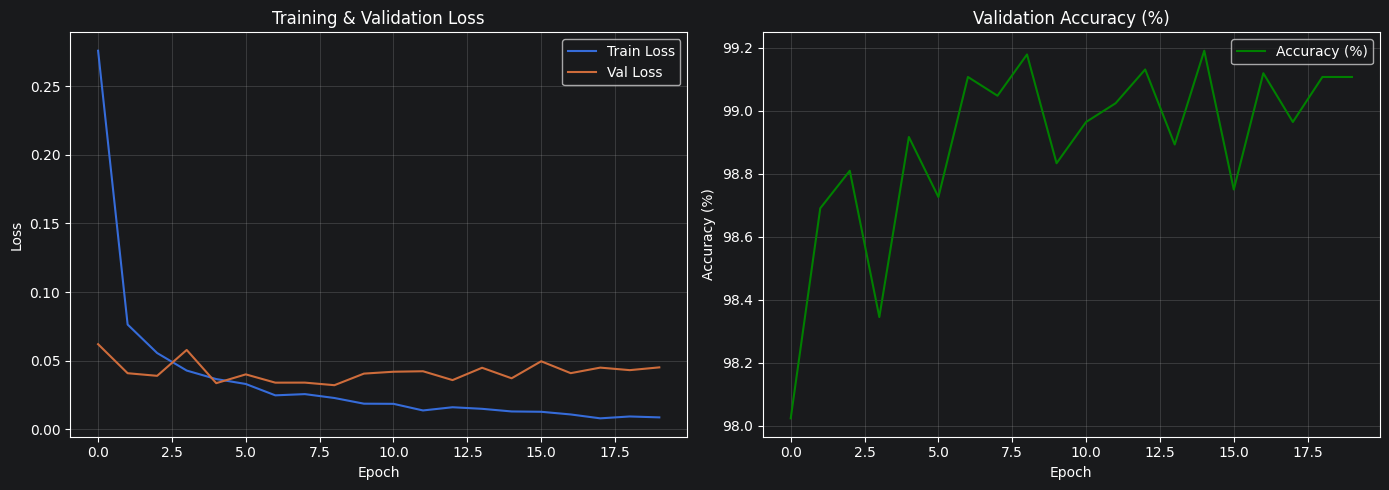

In [15]:
# Restore best weights and plot
checkpoint.restore_best_weights()

plot_training_curves(
    history["train_loss"],
    history["val_loss"],
    history["val_metric"],
    metric_label="Accuracy (%)"
)

In [16]:
# Save final production model and log run
torch.save(model.state_dict(), "./Models/digit_best_model_ultralight.pth")
print("Model saved to ./Models/digit_best_model_ultralight.pth")

save_run(
    "logs/digit_classifier_run_ultralight.json",
    model,
    history,
    epochs=epochs,
    batch_size=batch_size,
    optimizer="Adam"
)

Model saved to ./Models/digit_best_model_ultralight.pth
Run saved → logs/digit_classifier_run_ultralight.json
